/tmp/ipykernel_1062/3922125930.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2019-05-31", end="2020-06-30", freq='M')


✅ Data Setup Complete!



/tmp/ipykernel_1062/3922125930.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_avg, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')


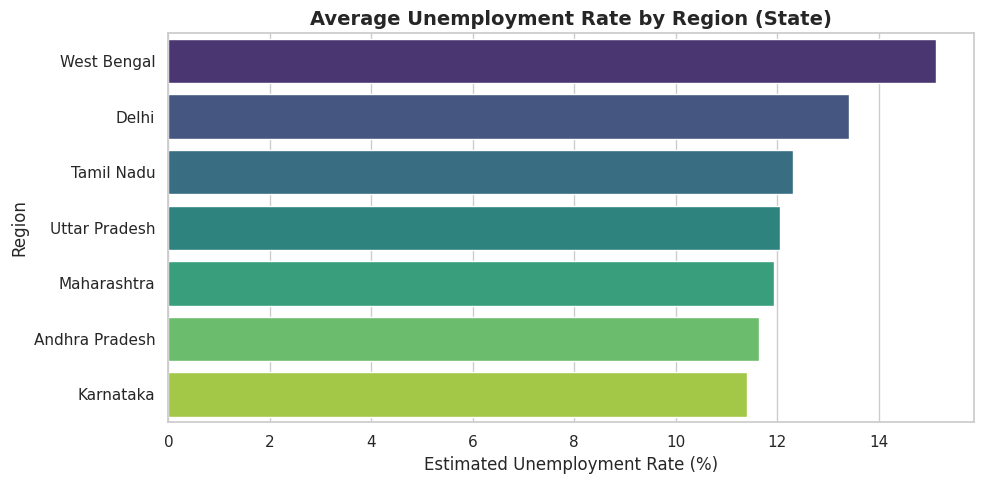

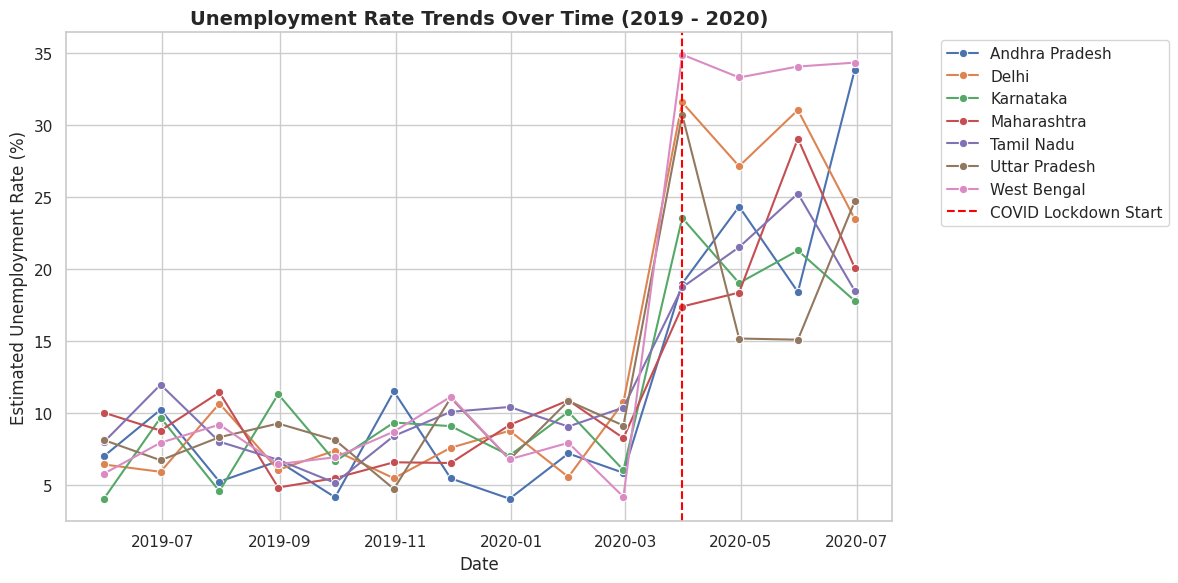

/tmp/ipykernel_1062/3922125930.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Period', y='Estimated Unemployment Rate (%)', palette='Set2')


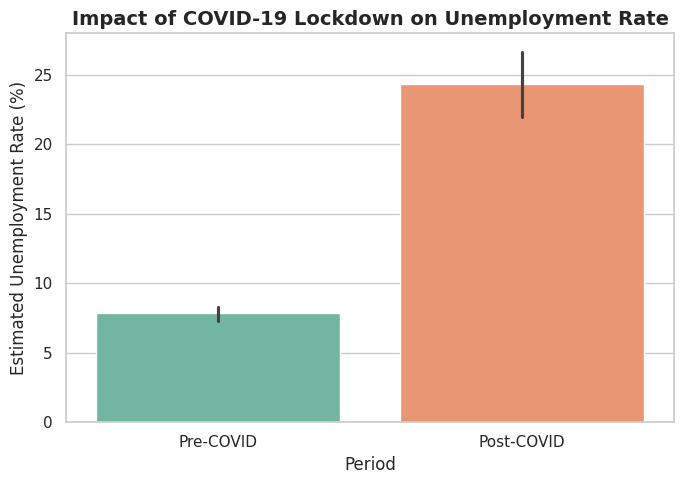

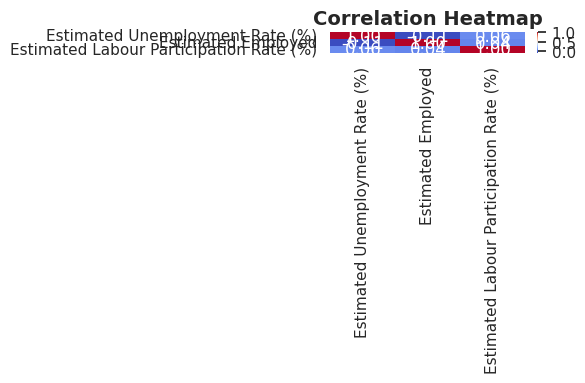

✅ All Task 2 Charts Generated Successfully!


In [ ]:
# ==========================================
# TASK 2: UNEMPLOYMENT ANALYSIS WITH PYTHON
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style set cheyadam
sns.set_theme(style="whitegrid")

# 1. Dataset Generation (Dummy Dataset creation for Task 2)
np.random.seed(42)
dates = pd.date_range(start="2019-05-31", end="2020-06-30", freq='M')
states = ['Andhra Pradesh', 'Delhi', 'Karnataka', 'Maharashtra', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']

data = []
for state in states:
    for date in dates:
        is_covid = date >= pd.to_datetime("2020-03-31")
        base_rate = np.random.uniform(15, 35) if is_covid else np.random.uniform(4, 12)

        data.append({
            'Region': state,
            'Date': date,
            'Frequency': 'Monthly',
            'Estimated Unemployment Rate (%)': round(base_rate, 2),
            'Estimated Employed': np.random.randint(5000000, 20000000),
            'Estimated Labour Participation Rate (%)': round(np.random.uniform(35, 50), 2)
        })

df = pd.DataFrame(data)

# CSV file ga save cheyadam
df.to_csv("Unemployment_in_India.csv", index=False)

# Data Cleaning steps
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

print("✅ Data Setup Complete!\n")

# 2. Visualizations (Graphs)

# Graph 1: Regional Unemployment Rate (State-wise)
plt.figure(figsize=(10, 5))
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
state_avg = state_avg.sort_values(by='Estimated Unemployment Rate (%)', ascending=False)
sns.barplot(data=state_avg, x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')
plt.title('Average Unemployment Rate by Region (State)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Graph 2: Time Series Trend (Time vs Rate)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')
plt.title('Unemployment Rate Trends Over Time (2019 - 2020)', fontsize=14, fontweight='bold')
plt.axvline(pd.to_datetime('2020-03-31'), color='red', linestyle='--', label='COVID Lockdown Start')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph 3: Pre-COVID vs Post-COVID Comparison
df['Period'] = np.where(df['Date'] < '2020-03-31', 'Pre-COVID', 'Post-COVID')
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Period', y='Estimated Unemployment Rate (%)', palette='Set2')
plt.title('Impact of COVID-19 Lockdown on Unemployment Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Graph 4: Correlation Heatmap
plt.figure(figsize=(6, 4))
numeric_df = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ All Task 2 Charts Generated Successfully!")